#### Make the Other Charts: Silly's Ice Cream Shop Project

I Scream, You Scream, We All Scream for `matplotlib` Charts!

#### Setup

In [9]:
# import matplotlib, colormap, and pandas
from matplotlib import pyplot as plt
import pandas as pd

# load data
ic_data = pd.read_csv('icecream_data.csv')

In [10]:
# display graphs correctly
%matplotlib inline
#plt.rcParams['figure.figsize'] = (5, 3)
#plt.rcParams['figure.dpi'] = 75

In [11]:
ic_data.head()

,day,date,day_of_week,day_of_week_num,humidity_afternoon,max_temp,sales_error,sales_total,top_flavor
0,1,08-01,monday,0,61,86,4.37,619.89,coffee
1,2,08-02,tuesday,1,59,87,2.92,562.28,moosetracks
2,3,08-03,wednesday,2,52,81,4.28,604.46,coffee
3,4,08-04,thursday,3,54,88,4.32,667.19,coffee
4,5,08-05,friday,4,54,87,8.91,693.86,coffee


#### Bar Chart

1. First up, **make a bar chart** to examine sales numbers for each day of the month. **Add a horiztonal AB line** at $640, the owner's benchmark for a successful sales day. **Add error bars** using the `sales_error` column. 

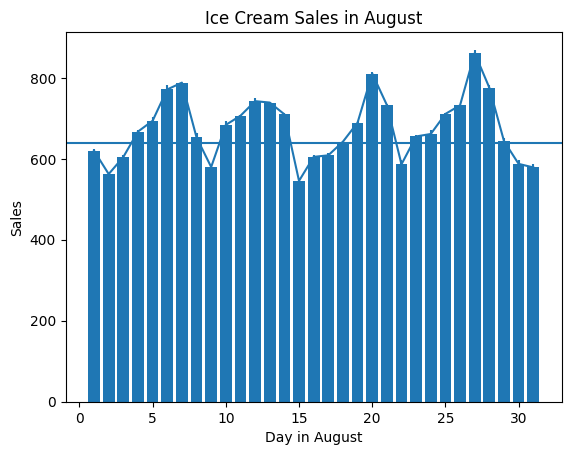

In [12]:
# make a bar chart
plt.bar(x=ic_data.day, height=ic_data.sales_total)
plt.axhline(640,0), (640,1)
plt.errorbar(ic_data.day, ic_data.sales_total, yerr=ic_data.sales_error)
plt.title('Ice Cream Sales in August')
plt.xlabel('Day in August')
plt.ylabel('Sales')
plt.show()

2. There definitely appears to be some kind of pattern, so let's visualize this data by day of the week. **Run the cell below** to create a new `avg_by_day` dataframe. This script groups the sales data by day of the week and returns the average sales data for each day, so that we can make one averaged bar for each day. (If you want to learn how to do this on your own using `pandas`, check out our Data Science with Python content!)

In [13]:
# create our averaged bar graph data
avg_by_day = ic_data.groupby([ic_data['day_of_week_num'], ic_data['day_of_week']])['sales_total'].mean()
avg_by_day = avg_by_day.droplevel(0,'index').reset_index(name='sales_avg')
avg_by_day

,day_of_week,sales_avg
0,monday,609.6780
1,tuesday,597.8500
2,wednesday,627.3640
3,thursday,681.6525
4,friday,714.4100
5,saturday,795.4200
6,sunday,751.6550


3. Using our new `avg_by_day` dataframe, **make a bar chart by day of the week** to help the owner see which day has the best sales, and which the worst. Add the **horizontal AB line** at $640 again for reference. If the owner decides to close up shop one or two days of the week, which days make most sense? 

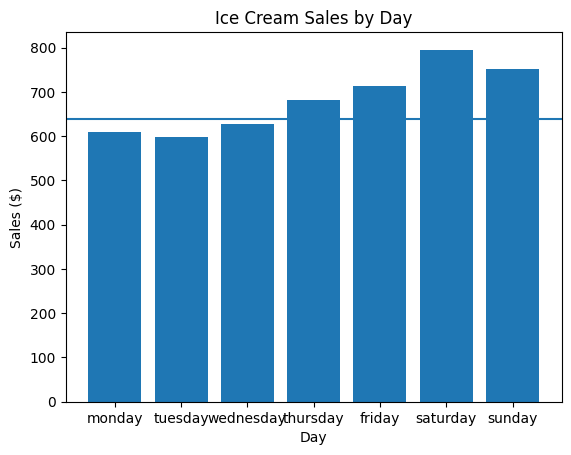

In [14]:
# make a bar chart by day of the week
plt.bar(x=avg_by_day.day_of_week, height = avg_by_day.sales_avg)
plt.axhline(640,0), (640.1)

plt.title('Ice Cream Sales by Day')
plt.xlabel('Day')
plt.ylabel('Sales ($)')
plt.show()

#### Pie Chart

4. Next, let's use a pie chart to visualize the top-selling flavors. Silly's serves 16 flavors of ice cream -- how many were the most popular flavor on at least one day in August? How do they compare to one another? **Run the cell below** to calculate the total count for each flavor that was listed as a top-seller in August. This code counts up the unique values in the `top_flavor` column of our original dataset and creates a new dataframe from them called `popular_flavors`. (Again, if you want to learn how to do this, check out our Data Science with Python course!)

In [5]:
# run this cell to create the data for our pie chart
# moosetracks is vanilla ice cream with mini peanut butter cups and fudge swirled in
popular_flavors = ic_data.top_flavor.value_counts().rename_axis('flavor').reset_index(name='count')
popular_flavors

,flavor,count
0,coffee,16
1,moosetracks,11
2,mint chip,4


5. **Create a pie chart** using the new `popular_flavors` dataframe. We recommend using `tan`, `saddlebrown`, and `lightgreen` for the three flavors.

TypeError: float() argument must be a string or a number, not 'method'

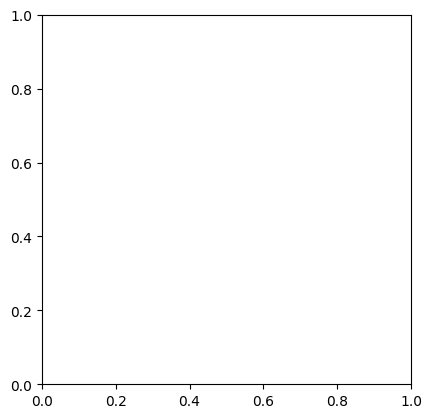

In [6]:
# pie chart
plt.pie(popular_flavors.count, labels = popular_flavors.flavor, colors=['tan', 'saddlebrown', 'lightgreen'])
plt.show()

#### Scatterplot

6. Now, the owner is curious about the impact of weather on sales. Using our original dataset again, **make two scatterplots in subplots** to compare the effect of temperature on ice cream sales, and the effect of humidity on ice cream sales. Should the owner consider adjusting the shop's opening hours or days based on weather predictions, or preparing for high volume days correlated with temperature or humidity?

#### Histogram

7. Finally, let's see how the sales data is distributed. **Make a 10-bin histogram** of the `sales_total` data.

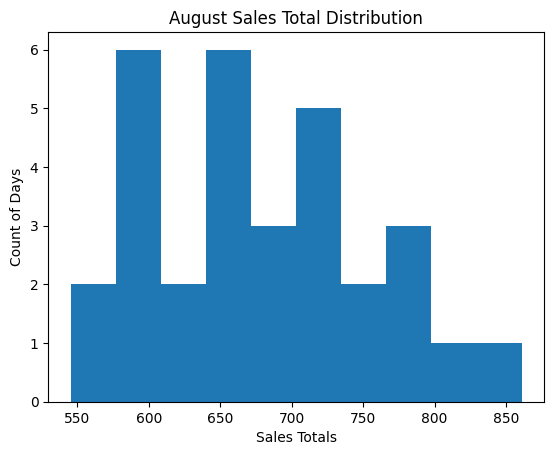

In [22]:
#histogram 
plt.hist(ic_data.sales_total, bins = 10)
plt.title('August Sales Total Distribution')
plt.xlabel('Sales Totals')
plt.ylabel('Count of Days')

plt.show()

8. **Add a vertical AB line** in a contrasting color at $640 to show the owner's benchmark for a successful day of sales. Is most of the data above or below that line? 

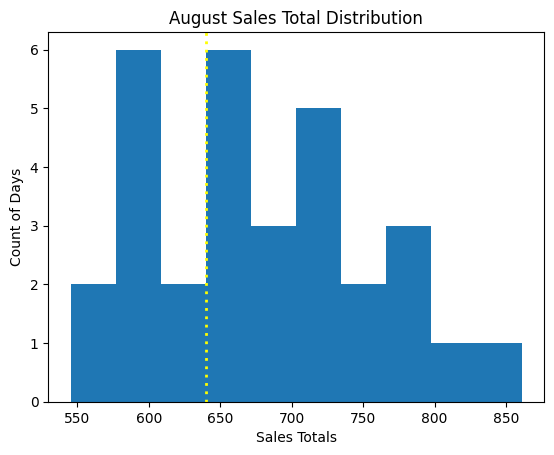

In [24]:
#histogram 
plt.hist(ic_data.sales_total, bins = 10)
plt.title('August Sales Total Distribution')
plt.xlabel('Sales Totals')
plt.ylabel('Count of Days')
plt.axline((640,0), (640,1), linewidth = 2, dashes = (1,2), color = 'yellow')

plt.show()

Let's look back on the original question. Silly’s Ice Cream Shop was considering implementing three different business strategies for next summer:

1. invest in a better weather tracking app to predict good weather days
2. close the shop one or two days a week to make staffing easier and more cost-effective
3. add more flavors to the menu to keep customers interested

<details>
    <summary style="display:list-item; font-size:16px; color:blue;"><i>So, what's the most important piece of data for Silly's to consider next summer? Should the owner invest in a good weather app? Change the shop's hours to be open on different days? Add new flavors?</i></summary>

Based on the charts, it seems like changing the shop's hours will have the biggest impact on the business. The bar graph shows that on average, the shop doesn't reach its $640 sales target on Mondays, Tuesdays and Wednesdays, so it might benefit Silly's to close on at least one of those days. <br><br>There seems to be no strong correlation between temperature or humidity and sales, so investing in a better weather app doesn't seem like a good use of resources. <br><br> Finally, just 3 flavors out of 16 made it into the top-seller category, so it seems like customers have favorite flavors and stick with them. However, more data is probably necessary to answer this question, since our data really only tells us that Coffee and Moosetracks are consistently popular flavors, not whether customers would like to try other flavors.</summary>